# Stan 4-Model LogML Distribution

Read the bridge-sampling log marginal likelihoods from `stan/results_4_models/empirical` and compare the four assumed models on the empirical datasets.

In [16]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path("/Users/yimingzang/Documents/Project/benchmark2")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DIFFUSION_DIR = PROJECT_ROOT / "benchmark" / "examples" / "diffusion"
RESULT_ROOT = DIFFUSION_DIR / "stan" / "results_4_models" / "empirical"
FIGURE_DIR = DIFFUSION_DIR / "results" / "plots" / "stan_4_models"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

MODEL_LABELS = {
    "m0": "M0: common threshold",
    "m1": "M1: threshold by condition",
    "m2": "M2: threshold by accumulator",
    "m3": "M3: condition x accumulator",
}
MODEL_ORDER = list(MODEL_LABELS)
MODEL_COLORS = {
    "m0": "#4C78A8",
    "m1": "#F58518",
    "m2": "#54A24B",
    "m3": "#B279A2",
}


In [17]:
def read_logml_results(result_root=RESULT_ROOT):
    frames = []
    for model in MODEL_ORDER:
        path = result_root / model / "bridgesampling.csv"
        if not path.exists():
            raise FileNotFoundError(path)
        frame = pd.read_csv(path)
        frame["model"] = model
        frame["model_label"] = MODEL_LABELS[model]
        frames.append(frame)
    out = pd.concat(frames, ignore_index=True)
    out["id_number"] = out["id"].str.extract(r"(\d+)").astype(int)
    out = out.sort_values(["id_number", "model"]).reset_index(drop=True)
    return out


logml = read_logml_results()
logml.head()


,id,estimate,sd,model,model_label,id_number
0,p0,71.808556,0.000606,m0,M0: common threshold,0
1,p0,88.269208,0.001083,m1,M1: threshold by condition,0
2,p0,69.808035,0.001171,m2,M2: threshold by accumulator,0
3,p0,84.568990,0.000748,m3,M3: condition x accumulator,0
4,p1,11.611132,0.000540,m0,M0: common threshold,1


In [18]:
summary = (
    logml.groupby(["model", "model_label"], sort=False)
    .agg(
        n=("estimate", "size"),
        mean_logml=("estimate", "mean"),
        median_logml=("estimate", "median"),
        sd_logml=("estimate", "std"),
        min_logml=("estimate", "min"),
        max_logml=("estimate", "max"),
        mean_bridge_sd=("sd", "mean"),
        max_bridge_sd=("sd", "max"),
    )
    .reset_index()
)
summary


,model,model_label,n,mean_logml,median_logml,sd_logml,min_logml,max_logml,mean_bridge_sd,max_bridge_sd
0,m0,M0: common threshold,17,-10.527314,-9.921732,135.289294,-324.950099,167.837266,0.000636,0.001559
1,m1,M1: threshold by condition,17,38.948485,37.335670,122.954061,-202.912676,223.169374,0.000796,0.001462
2,m2,M2: threshold by accumulator,17,-7.981512,3.969435,135.450179,-326.953590,166.361019,0.000747,0.001342
3,m3,M3: condition x accumulator,17,42.106362,57.456636,121.615281,-203.307063,219.278042,0.000774,0.001285


In [19]:
wide = logml.pivot(index="id", columns="model", values="estimate")[MODEL_ORDER]
wide["best_model"] = wide[MODEL_ORDER].idxmax(axis=1)
wide["best_logml"] = wide[MODEL_ORDER].max(axis=1)
wide["second_best_logml"] = np.sort(wide[MODEL_ORDER].to_numpy(), axis=1)[:, -2]
wide["best_minus_second"] = wide["best_logml"] - wide["second_best_logml"]
wide = wide.reset_index()

best_counts = wide["best_model"].value_counts().reindex(MODEL_ORDER, fill_value=0).rename_axis("model").reset_index(name="n_best")
best_counts["model_label"] = best_counts["model"].map(MODEL_LABELS)
best_counts


,model,n_best,model_label
0,m0,0,M0: common threshold
1,m1,8,M1: threshold by condition
2,m2,0,M2: threshold by accumulator
3,m3,9,M3: condition x accumulator


## Distribution Across Participants

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/stan_4_models/stan_4_models_logml_distribution.png


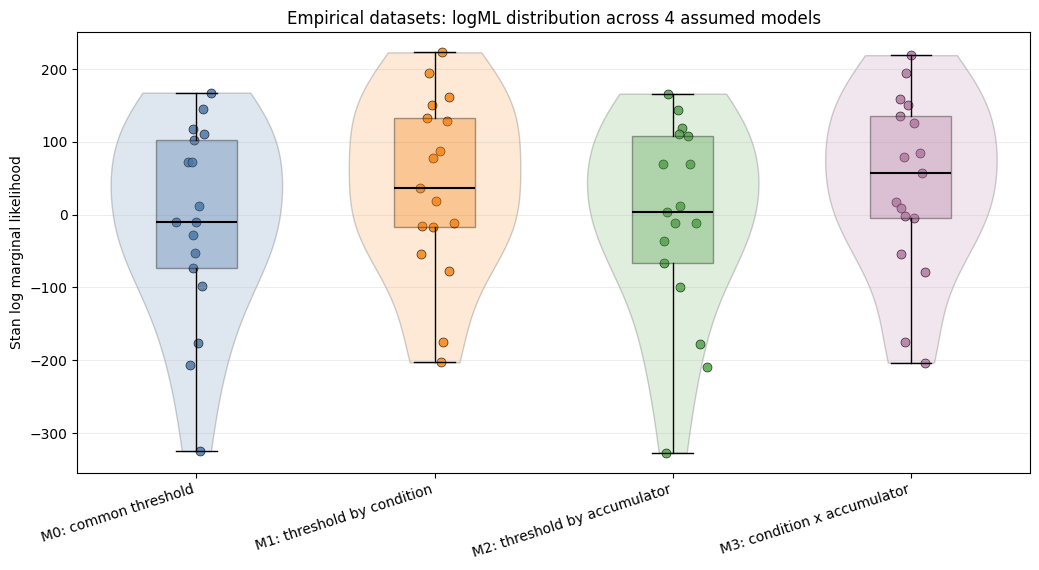

In [20]:
def plot_logml_distribution(logml, filename="stan_4_models_logml_distribution.png"):
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    data = [logml.loc[logml["model"].eq(model), "estimate"].to_numpy() for model in MODEL_ORDER]
    positions = np.arange(len(MODEL_ORDER))

    violin = ax.violinplot(data, positions=positions, widths=0.72, showmeans=False, showmedians=False, showextrema=False)
    for body, model in zip(violin["bodies"], MODEL_ORDER, strict=False):
        body.set_facecolor(MODEL_COLORS[model])
        body.set_edgecolor("black")
        body.set_alpha(0.18)

    box = ax.boxplot(
        data,
        positions=positions,
        widths=0.34,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
        boxprops={"linewidth": 1.0},
        whiskerprops={"linewidth": 1.0},
        capprops={"linewidth": 1.0},
    )
    for patch, model in zip(box["boxes"], MODEL_ORDER, strict=False):
        patch.set_facecolor(MODEL_COLORS[model])
        patch.set_alpha(0.35)

    rng = np.random.default_rng(2026)
    for pos, model in zip(positions, MODEL_ORDER, strict=False):
        y = logml.loc[logml["model"].eq(model), "estimate"].to_numpy()
        x = pos + rng.normal(0.0, 0.045, size=len(y))
        ax.scatter(x, y, s=42, color=MODEL_COLORS[model], edgecolor="black", linewidth=0.45, alpha=0.85)

    ax.set_xticks(positions)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], rotation=18, ha="right")
    ax.set_ylabel("Stan log marginal likelihood")
    ax.set_title("Empirical datasets: logML distribution across 4 assumed models")
    ax.grid(axis="y", alpha=0.22)
    fig.tight_layout()

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(path)
    return fig, ax


fig_dist, ax_dist = plot_logml_distribution(logml)


## Participant-Wise Comparison

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/stan_4_models/stan_4_models_logml_by_participant.png


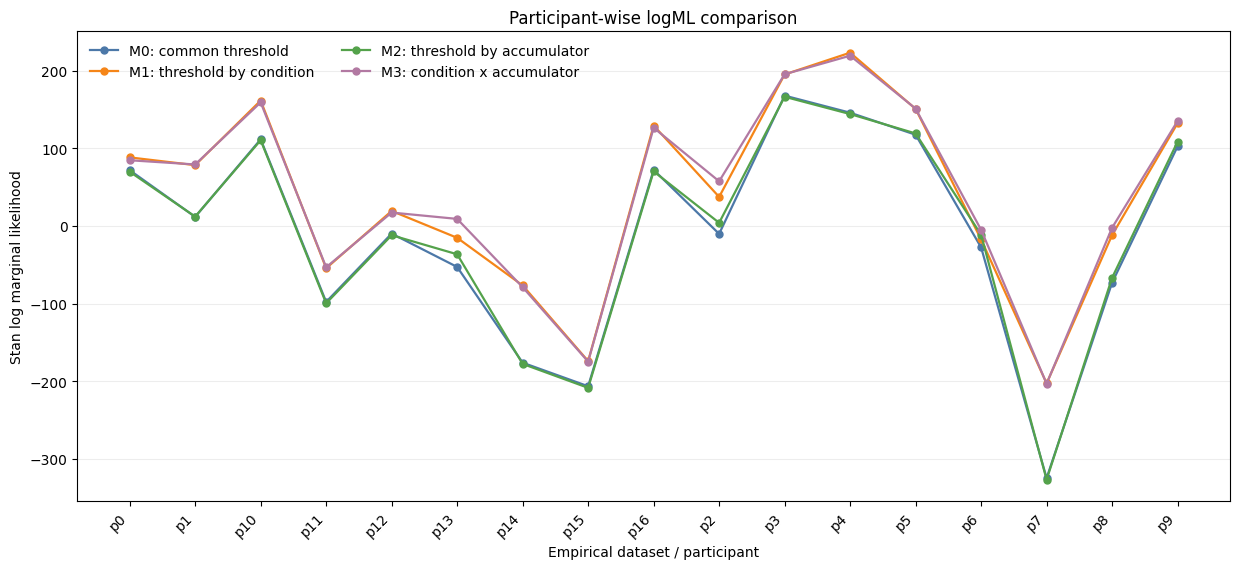

In [21]:
def plot_logml_by_participant(logml, filename="stan_4_models_logml_by_participant.png"):
    wide_plot = logml.pivot(index="id", columns="model", values="estimate")[MODEL_ORDER]
    ids = wide_plot.index.tolist()
    x = np.arange(len(ids))

    fig, ax = plt.subplots(figsize=(12.5, 5.8))
    for model in MODEL_ORDER:
        ax.plot(x, wide_plot[model], marker="o", linewidth=1.6, markersize=5.0, color=MODEL_COLORS[model], label=MODEL_LABELS[model])

    ax.set_xticks(x)
    ax.set_xticklabels(ids, rotation=45, ha="right")
    ax.set_ylabel("Stan log marginal likelihood")
    ax.set_xlabel("Empirical dataset / participant")
    ax.set_title("Participant-wise logML comparison")
    ax.grid(axis="y", alpha=0.22)
    ax.legend(frameon=False, ncol=2)
    fig.tight_layout()

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(path)
    return fig, ax


fig_participant, ax_participant = plot_logml_by_participant(logml)


## Differences Relative to M0

In [22]:
diff_from_m0 = wide[["id"] + MODEL_ORDER].copy()
for model in MODEL_ORDER[1:]:
    diff_from_m0[f"{model}_minus_m0"] = diff_from_m0[model] - diff_from_m0["m0"]

diff_from_m0[["id", "m1_minus_m0", "m2_minus_m0", "m3_minus_m0"]]


model,id,m1_minus_m0,m2_minus_m0,m3_minus_m0
0,p0,16.460652,-2.000521,12.760435
1,p1,66.649316,0.332852,67.522063
2,p10,49.967097,-1.165223,47.577216
3,p11,43.337144,-1.784257,44.604369
4,p12,29.149175,-2.111716,27.113859
5,p13,37.543591,16.325880,61.896511
6,p14,99.542851,-1.576784,97.271347
7,p15,32.384434,-2.059060,31.729103
8,p16,57.120740,-1.959226,54.240271
9,p2,47.629000,14.262766,67.749966


/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/stan_4_models/stan_4_models_logml_difference_from_m0.png


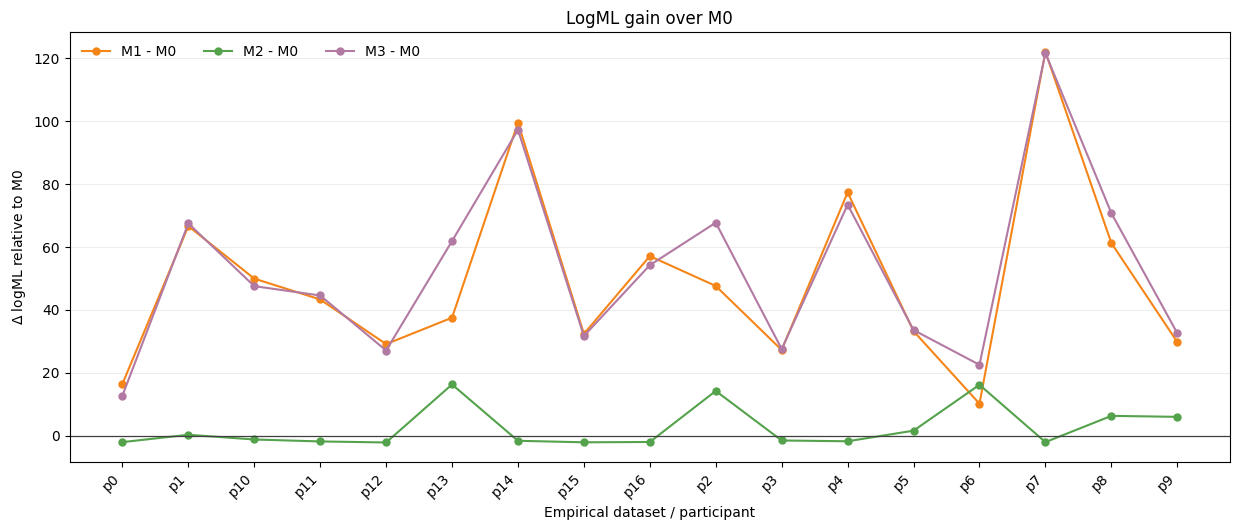

In [23]:
def plot_logml_difference_from_m0(diff_from_m0, filename="stan_4_models_logml_difference_from_m0.png"):
    diff_cols = ["m1_minus_m0", "m2_minus_m0", "m3_minus_m0"]
    labels = ["M1 - M0", "M2 - M0", "M3 - M0"]
    colors = [MODEL_COLORS["m1"], MODEL_COLORS["m2"], MODEL_COLORS["m3"]]
    ids = diff_from_m0["id"].tolist()
    x = np.arange(len(ids))

    fig, ax = plt.subplots(figsize=(12.5, 5.4))
    for col, label, color in zip(diff_cols, labels, colors, strict=False):
        ax.plot(x, diff_from_m0[col], marker="o", linewidth=1.5, markersize=5.0, color=color, label=label)

    ax.axhline(0.0, color="0.25", linewidth=0.9)
    ax.set_xticks(x)
    ax.set_xticklabels(ids, rotation=45, ha="right")
    ax.set_ylabel(r"$\Delta$ logML relative to M0")
    ax.set_xlabel("Empirical dataset / participant")
    ax.set_title("LogML gain over M0")
    ax.grid(axis="y", alpha=0.22)
    ax.legend(frameon=False, ncol=3)
    fig.tight_layout()

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(path)
    return fig, ax


fig_diff, ax_diff = plot_logml_difference_from_m0(diff_from_m0)


## Posterior Model Probabilities

In [24]:
def compute_pmp_from_logml(logml):
    wide_logml = logml.pivot(index="id", columns="model", values="estimate")[MODEL_ORDER]
    centered = wide_logml.sub(wide_logml.max(axis=1), axis=0)
    probs = np.exp(centered)
    probs = probs.div(probs.sum(axis=1), axis=0)

    pmp_wide = probs.reset_index()
    pmp_long = pmp_wide.melt(id_vars="id", var_name="model", value_name="pmp")
    pmp_long["model_label"] = pmp_long["model"].map(MODEL_LABELS)
    pmp_long["id_number"] = pmp_long["id"].str.extract(r"(\d+)").astype(int)
    pmp_long = pmp_long.sort_values(["id_number", "model"]).reset_index(drop=True)
    return pmp_wide, pmp_long


pmp_wide, pmp_long = compute_pmp_from_logml(logml)
pmp_path = DIFFUSION_DIR / "results" / "stan_4_models_pmp_estimates.csv"
pmp_long.to_csv(pmp_path, index=False)
print(pmp_path)
pmp_wide.head()

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/stan_4_models_pmp_estimates.csv


model,id,m0,m1,m2,m3
0,p0,6.928273e-08,0.975878,9.371519e-09,0.024122
1,p1,3.341374e-30,0.294683,4.661018e-30,0.705317
2,p10,1.825937e-22,0.916052,5.694242e-23,0.083948
3,p11,3.317510e-20,0.219733,5.570824e-21,0.780267
4,p12,1.937983e-13,0.884455,2.345543e-14,0.115545


In [25]:
pmp_summary = (
    pmp_long.groupby(["model", "model_label"], sort=False)
    .agg(
        n=("pmp", "size"),
        mean_pmp=("pmp", "mean"),
        median_pmp=("pmp", "median"),
        sd_pmp=("pmp", "std"),
        min_pmp=("pmp", "min"),
        max_pmp=("pmp", "max"),
    )
    .reset_index()
)
pmp_summary

,model,model_label,n,mean_pmp,median_pmp,sd_pmp,min_pmp,max_pmp
0,m0,M0: common threshold,17,4.084726e-09,1.825937e-22,1.680118e-08,5.970915e-54,6.928273e-08
1,m1,M1: threshold by condition,17,4.870390e-01,4.261675e-01,3.955851e-01,2.652535e-11,9.799904e-01
2,m2,M2: threshold by accumulator,17,1.017883e-04,5.570824e-21,4.196817e-04,8.052601e-55,1.730393e-03
3,m3,M3: condition x accumulator,17,5.128592e-01,5.738325e-01,3.954522e-01,2.000957e-02,1.000000e+00


/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/stan_4_models/stan_4_models_pmp_distribution.png


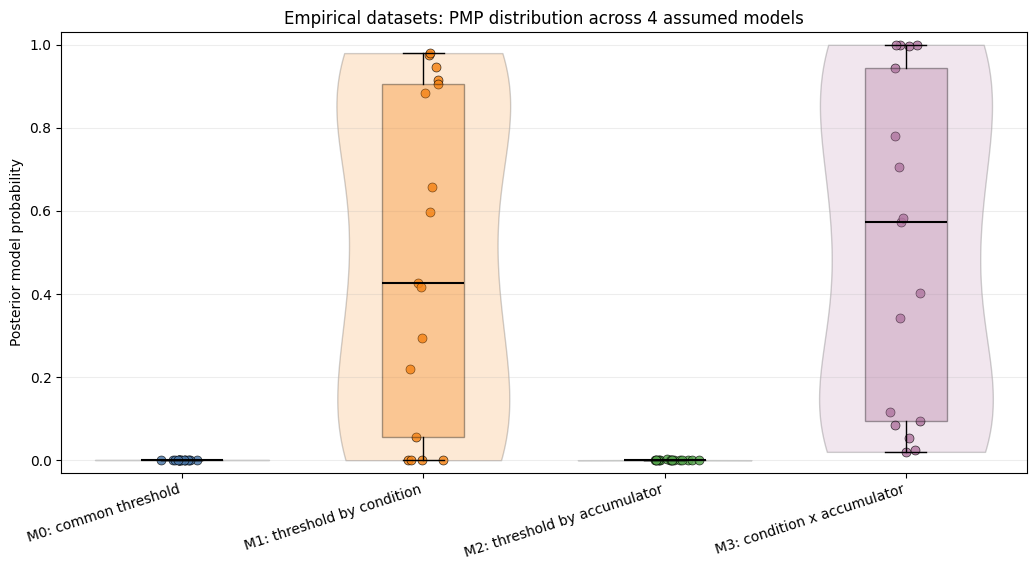

In [26]:
def plot_pmp_distribution(pmp_long, filename="stan_4_models_pmp_distribution.png", title=None):
    fig, ax = plt.subplots(figsize=(10.5, 5.8))
    data = [pmp_long.loc[pmp_long["model"].eq(model), "pmp"].to_numpy() for model in MODEL_ORDER]
    positions = np.arange(len(MODEL_ORDER))

    violin = ax.violinplot(data, positions=positions, widths=0.72, showmeans=False, showmedians=False, showextrema=False)
    for body, model in zip(violin["bodies"], MODEL_ORDER, strict=False):
        body.set_facecolor(MODEL_COLORS[model])
        body.set_edgecolor("black")
        body.set_alpha(0.18)

    box = ax.boxplot(
        data,
        positions=positions,
        widths=0.34,
        patch_artist=True,
        showfliers=False,
        medianprops={"color": "black", "linewidth": 1.5},
        boxprops={"linewidth": 1.0},
        whiskerprops={"linewidth": 1.0},
        capprops={"linewidth": 1.0},
    )
    for patch, model in zip(box["boxes"], MODEL_ORDER, strict=False):
        patch.set_facecolor(MODEL_COLORS[model])
        patch.set_alpha(0.35)

    rng = np.random.default_rng(2026)
    for pos, model in zip(positions, MODEL_ORDER, strict=False):
        y = pmp_long.loc[pmp_long["model"].eq(model), "pmp"].to_numpy()
        x = pos + rng.normal(0.0, 0.045, size=len(y))
        ax.scatter(x, y, s=42, color=MODEL_COLORS[model], edgecolor="black", linewidth=0.45, alpha=0.85)

    ax.set_xticks(positions)
    ax.set_xticklabels([MODEL_LABELS[m] for m in MODEL_ORDER], rotation=18, ha="right")
    ax.set_ylim(-0.03, 1.03)
    ax.set_ylabel("Posterior model probability")
    ax.set_title(title or "Empirical datasets: PMP distribution across 4 assumed models")
    ax.grid(axis="y", alpha=0.22)
    fig.tight_layout()

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(path)
    return fig, ax


fig_pmp, ax_pmp = plot_pmp_distribution(pmp_long)

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/stan_4_models/stan_4_models_pmp_by_participant.png


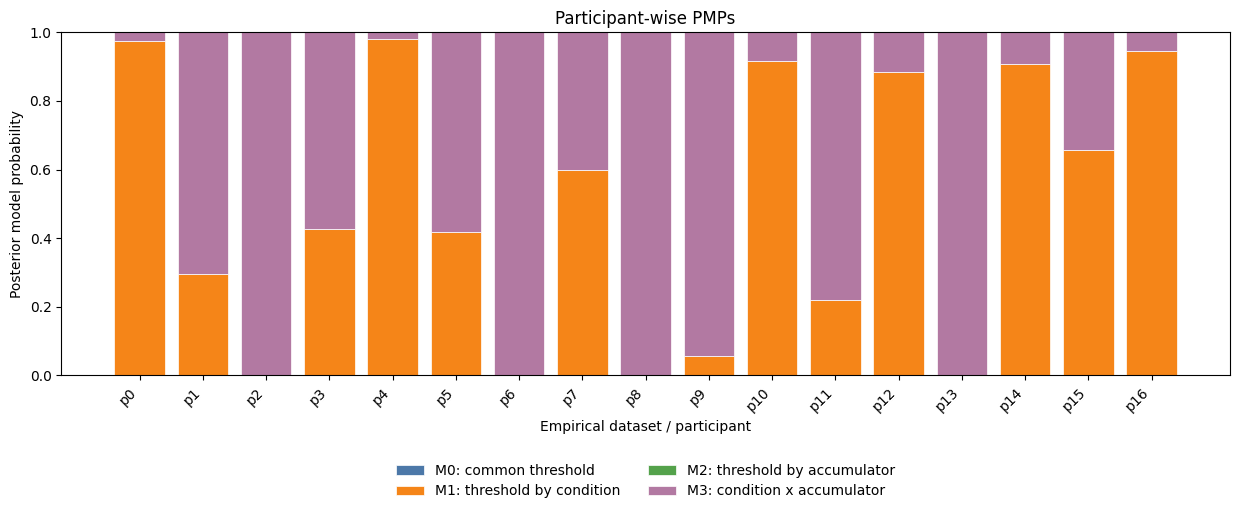

In [27]:
def plot_pmp_by_participant(pmp_wide, filename="stan_4_models_pmp_by_participant.png"):
    pmp_plot = pmp_wide.copy()
    pmp_plot["id_number"] = pmp_plot["id"].str.extract(r"(\d+)").astype(int)
    pmp_plot = pmp_plot.sort_values("id_number")

    ids = pmp_plot["id"].tolist()
    x = np.arange(len(ids))
    bottom = np.zeros(len(ids))

    fig, ax = plt.subplots(figsize=(12.5, 5.4))
    for model in MODEL_ORDER:
        values = pmp_plot[model].to_numpy()
        ax.bar(x, values, bottom=bottom, color=MODEL_COLORS[model], edgecolor="white", linewidth=0.5, label=MODEL_LABELS[model])
        bottom += values

    ax.set_xticks(x)
    ax.set_xticklabels(ids, rotation=45, ha="right")
    ax.set_ylim(0.0, 1.0)
    ax.set_ylabel("Posterior model probability")
    ax.set_xlabel("Empirical dataset / participant")
    ax.set_title("Participant-wise PMPs")
    ax.legend(frameon=False, ncol=2, loc="upper center", bbox_to_anchor=(0.5, -0.22))
    fig.tight_layout()

    path = FIGURE_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    print(path)
    return fig, ax


fig_pmp_participant, ax_pmp_participant = plot_pmp_by_participant(pmp_wide)

## Participant-Level PMP Table

In [28]:
pmp_participant_table = pmp_wide.copy()
pmp_participant_table["id_number"] = pmp_participant_table["id"].str.extract(r"(\d+)").astype(int)
pmp_participant_table = pmp_participant_table.sort_values("id_number").drop(columns="id_number").reset_index(drop=True)
pmp_participant_table["mean_pmp"] = pmp_participant_table[MODEL_ORDER].mean(axis=1)
pmp_participant_table["median_pmp"] = pmp_participant_table[MODEL_ORDER].median(axis=1)
pmp_participant_table["mode_model"] = pmp_participant_table[MODEL_ORDER].idxmax(axis=1)
pmp_participant_table["mode_pmp"] = pmp_participant_table[MODEL_ORDER].max(axis=1)

pmp_table_path = DIFFUSION_DIR / "results" / "stan_4_models_pmp_participant_table.csv"
pmp_participant_table.to_csv(pmp_table_path, index=False)
print(pmp_table_path)
pmp_participant_table

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/stan_4_models_pmp_participant_table.csv


model,id,m0,m1,m2,m3,mean_pmp,median_pmp,mode_model,mode_pmp
0,p0,6.928273e-08,9.758780e-01,9.371519e-09,0.024122,0.25,1.206098e-02,m1,0.975878
1,p1,3.341374e-30,2.946830e-01,4.661018e-30,0.705317,0.25,1.473415e-01,m3,0.705317
2,p2,3.771930e-30,1.826314e-09,5.899348e-24,1.000000,0.25,9.131571e-10,m3,1.000000
3,p3,5.983820e-13,4.261675e-01,1.367265e-13,0.573832,0.25,2.130838e-01,m3,0.573832
4,p4,2.489368e-34,9.799904e-01,4.399109e-35,0.020010,0.25,1.000479e-02,m1,0.979990
5,p5,1.466121e-15,4.169979e-01,7.539907e-15,0.583002,0.25,2.084989e-01,m3,0.583002
6,p6,1.568121e-10,4.284786e-06,1.730393e-03,0.998265,0.25,8.673387e-04,m3,0.998265
7,p7,5.970915e-54,5.973384e-01,8.052601e-55,0.402662,0.25,2.013308e-01,m1,0.597338
8,p8,1.810249e-31,7.591326e-05,1.027280e-28,0.999924,0.25,3.795663e-05,m3,0.999924
9,p9,6.340414e-15,5.671474e-02,2.639804e-12,0.943285,0.25,2.835737e-02,m3,0.943285


## Raw-Exponent PMP Check

In [29]:
def compute_pmp_from_logml_raw(logml):
    wide_logml = logml.pivot(index="id", columns="model", values="estimate")[MODEL_ORDER]
    exp_logml = np.exp(wide_logml)
    probs = exp_logml.div(exp_logml.sum(axis=1), axis=0)

    pmp_wide = probs.reset_index()
    pmp_long = pmp_wide.melt(id_vars="id", var_name="model", value_name="pmp")
    pmp_long["model_label"] = pmp_long["model"].map(MODEL_LABELS)
    pmp_long["id_number"] = pmp_long["id"].str.extract(r"(\d+)").astype(int)
    pmp_long = pmp_long.sort_values(["id_number", "model"]).reset_index(drop=True)
    return pmp_wide, pmp_long


pmp_raw_wide, pmp_raw_long = compute_pmp_from_logml_raw(logml)
pmp_raw_path = DIFFUSION_DIR / "results" / "stan_4_models_pmp_estimates_raw_exp.csv"
pmp_raw_long.to_csv(pmp_raw_path, index=False)
print(pmp_raw_path)
pmp_raw_wide.head()

/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/stan_4_models_pmp_estimates_raw_exp.csv


model,id,m0,m1,m2,m3
0,p0,6.928273e-08,0.975878,9.371519e-09,0.024122
1,p1,3.341374e-30,0.294683,4.661018e-30,0.705317
2,p10,1.825937e-22,0.916052,5.694242e-23,0.083948
3,p11,3.317510e-20,0.219733,5.570824e-21,0.780267
4,p12,1.937983e-13,0.884455,2.345543e-14,0.115545


In [30]:
pmp_raw_summary = (
    pmp_raw_long.groupby(["model", "model_label"], sort=False)
    .agg(
        n=("pmp", "size"),
        mean_pmp=("pmp", "mean"),
        median_pmp=("pmp", "median"),
        sd_pmp=("pmp", "std"),
        min_pmp=("pmp", "min"),
        max_pmp=("pmp", "max"),
    )
    .reset_index()
)
pmp_raw_summary

,model,model_label,n,mean_pmp,median_pmp,sd_pmp,min_pmp,max_pmp
0,m0,M0: common threshold,17,4.084726e-09,1.825937e-22,1.680118e-08,5.970915e-54,6.928273e-08
1,m1,M1: threshold by condition,17,4.870390e-01,4.261675e-01,3.955851e-01,2.652535e-11,9.799904e-01
2,m2,M2: threshold by accumulator,17,1.017883e-04,5.570824e-21,4.196817e-04,8.052601e-55,1.730393e-03
3,m3,M3: condition x accumulator,17,5.128592e-01,5.738325e-01,3.954522e-01,2.000957e-02,1.000000e+00


/Users/yimingzang/Documents/Project/benchmark2/benchmark/examples/diffusion/results/plots/stan_4_models/stan_4_models_pmp_distribution_raw_exp.png


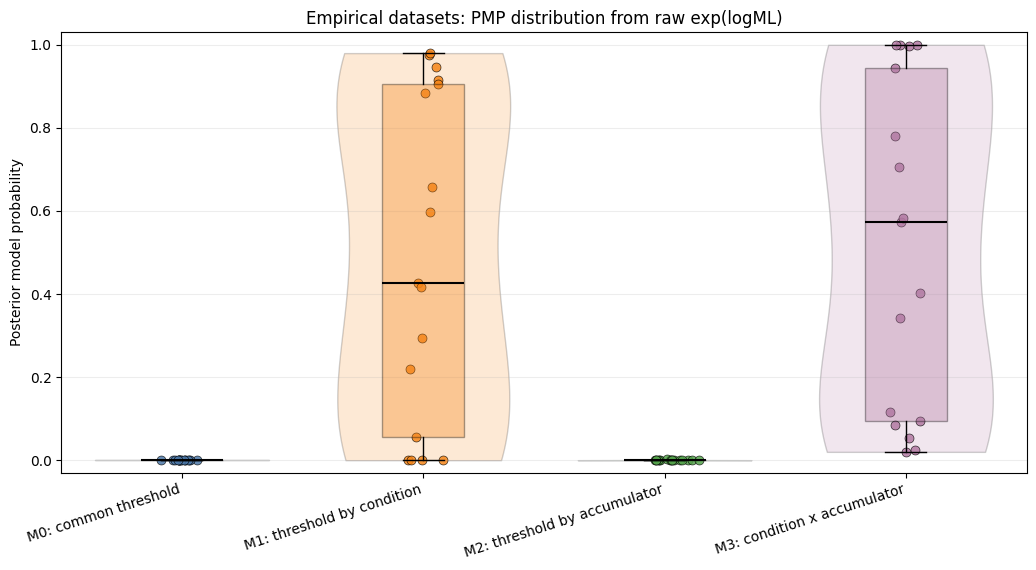

In [31]:
fig_pmp_raw, ax_pmp_raw = plot_pmp_distribution(
    pmp_raw_long,
    filename="stan_4_models_pmp_distribution_raw_exp.png",
    title="Empirical datasets: PMP distribution from raw exp(logML)",
)